Task 1: Environment and Data Acquisition
To reproduce this environment please run: `pip install -r requirements.txt`

# Task 1: Data Acquisition and Preparation

**Dataset Name:** Brain Tumor Dataset  
**URL:** [https://www.kaggle.com/datasets/jakeshbohaju/brain-tumor](https://www.kaggle.com/datasets/jakeshbohaju/brain-tumor)  
**License:** CC0: Public Domain  

**Description:**
This dataset contains 3,762 samples of brain MRI features extracted using image processing techniques, and it includes a total of 15 columns. Each row represents one image, with features that describe its intensity and texture.

It contains 13 numerical features such as Mean, Variance, Standard Deviation, Skewness, and Kurtosis, which capture the distribution of pixel intensities. In addition, there are texture-based features like Contrast, Energy, ASM (Angular Second Moment), Entropy, Homogeneity, Dissimilarity, Correlation, and Coarseness, which describe patterns and relationships between pixels in the image.

The Image column represents the file name of each MRI scan, while the target variable Class indicates whether a tumor is present (1) or not (0).

We chose this dataset because it provides meaningful numerical features that make it easier to analyze brain images and build machine learning models for tumor detection.

Required Inputs

    File Path: ../data/brain_tumor_dataset.csv (The raw dataset containing 3,762 MRI texture features).

Outputs Produced

    Cleaned Data: ../data/cleaned.csv (Dataset with duplicates removed and new features added).

    Visualizations: Distribution plots, correlation heatmaps, and bivariate scatter plots highlighting class separation.


In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
data = pd.read_csv('../data/raw/Brain Tumor.csv')
data.head()

,Image,Class,Mean,Variance,Standard Deviation,Entropy,Skewness,Kurtosis,Contrast,Energy,ASM,Homogeneity,Dissimilarity,Correlation,Coarseness
0,Image1,0,6.535339,619.587845,24.891522,0.109059,4.276477,18.900575,98.613971,0.293314,0.086033,0.530941,4.473346,0.981939,7.458341e-155
1,Image2,0,8.749969,805.957634,28.389393,0.266538,3.718116,14.464618,63.858816,0.475051,0.225674,0.651352,3.220072,0.988834,7.458341e-155
2,Image3,1,7.341095,1143.808219,33.820234,0.001467,5.061750,26.479563,81.867206,0.031917,0.001019,0.268275,5.981800,0.978014,7.458341e-155
3,Image4,1,5.958145,959.711985,30.979219,0.001477,5.677977,33.428845,151.229741,0.032024,0.001026,0.243851,7.700919,0.964189,7.458341e-155
4,Image5,0,7.315231,729.540579,27.010009,0.146761,4.283221,19.079108,174.988756,0.343849,0.118232,0.501140,6.834689,0.972789,7.458341e-155


In [60]:
data = data.drop('Image', axis=1)

print("Data Shape:", data.shape)
data.info()

Data Shape: (3762, 14)
<class 'pandas.DataFrame'>
RangeIndex: 3762 entries, 0 to 3761
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Class               3762 non-null   int64  
 1   Mean                3762 non-null   float64
 2   Variance            3762 non-null   float64
 3   Standard Deviation  3762 non-null   float64
 4   Entropy             3762 non-null   float64
 5   Skewness            3762 non-null   float64
 6   Kurtosis            3762 non-null   float64
 7   Contrast            3762 non-null   float64
 8   Energy              3762 non-null   float64
 9   ASM                 3762 non-null   float64
 10  Homogeneity         3762 non-null   float64
 11  Dissimilarity       3762 non-null   float64
 12  Correlation         3762 non-null   float64
 13  Coarseness          3762 non-null   float64
dtypes: float64(13), int64(1)
memory usage: 411.6 KB


Here are the feature representation and their meanings:

Class: Target variable where 0 indicates a healthy brain and 1 indicates a tumor presence.

Mean: Represents the average pixel intensity (brightness) of the MRI scan.

Variance: Measures the spread of pixel intensities; higher variance often indicates complex textures

Standard Deviation: The square root of variance, indicating intensity consistency.

Entropy: A measure of randomness; tumors often change the structural randomness of brain tissue.

Skewness/Kurtosis: Measure the shape and "tailedness" of the pixel intensity distribution.

Contrast/Energy/ASM: Textural features that describe the local variations and uniformity in the image.


In [61]:
print("Total Missing Values:", data.isnull().sum().sum())
print("Duplicates found:", data.duplicated().sum())
data = data.drop_duplicates()

Total Missing Values: 0
Duplicates found: 63


Audit was performed to ensure the integrity of the MRI feature set:

Missing Values: The audit returned 0 missing values across all features. No imputation or row removal was necessary.

Duplicates: 63 duplicate rows were identified. Decision: These rows were dropped to prevent data leakage and ensure that the machine learning models do not overfit to redundant data points.

Question 1: Is the dataset balanced between healthy and tumor samples?



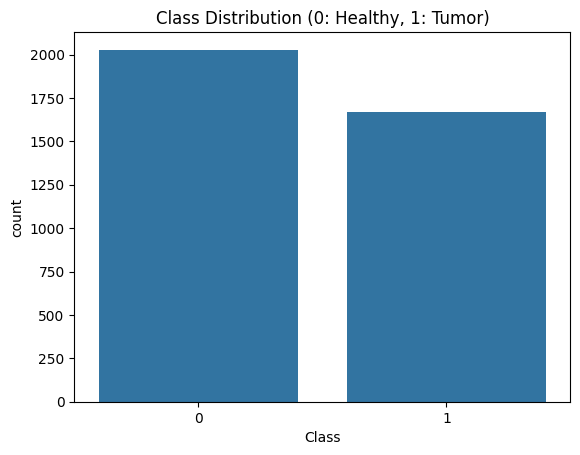

In [62]:
sns.countplot(x='Class', data=data)
plt.title('Class Distribution (0: Healthy, 1: Tumor)')
plt.show()

Observation: The count plot shows a relatively even distribution, with slightly more healthy (Class 0) than tumorous (Class 1) samples.

Question 2: Can the randomness of pixel intensities (Entropy) serve as a strong indicator for tumor presence?


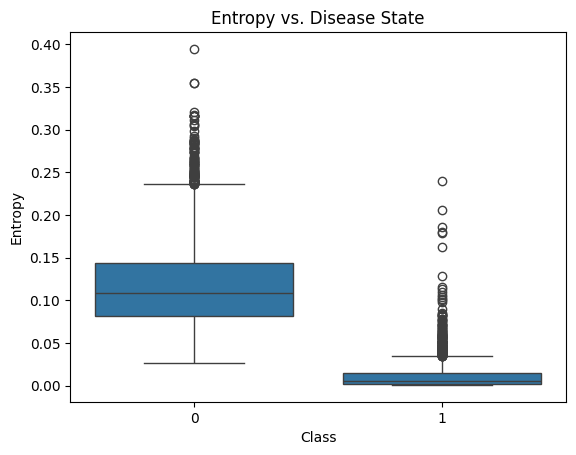

In [63]:
sns.boxplot(x='Class', y='Entropy', data=data)
plt.title('Entropy vs. Disease State')
plt.show()

Observation: The boxplot demonstrates that tumorous scans (Class 1) exhibit significantly lower median entropy and a much tighter distribution compared to healthy scans (Class 0). This clear separation between the two classes suggests that entropy is a highly discriminative feature for tumor detection.

Question 3: Which features are most strongly correlated with each other?


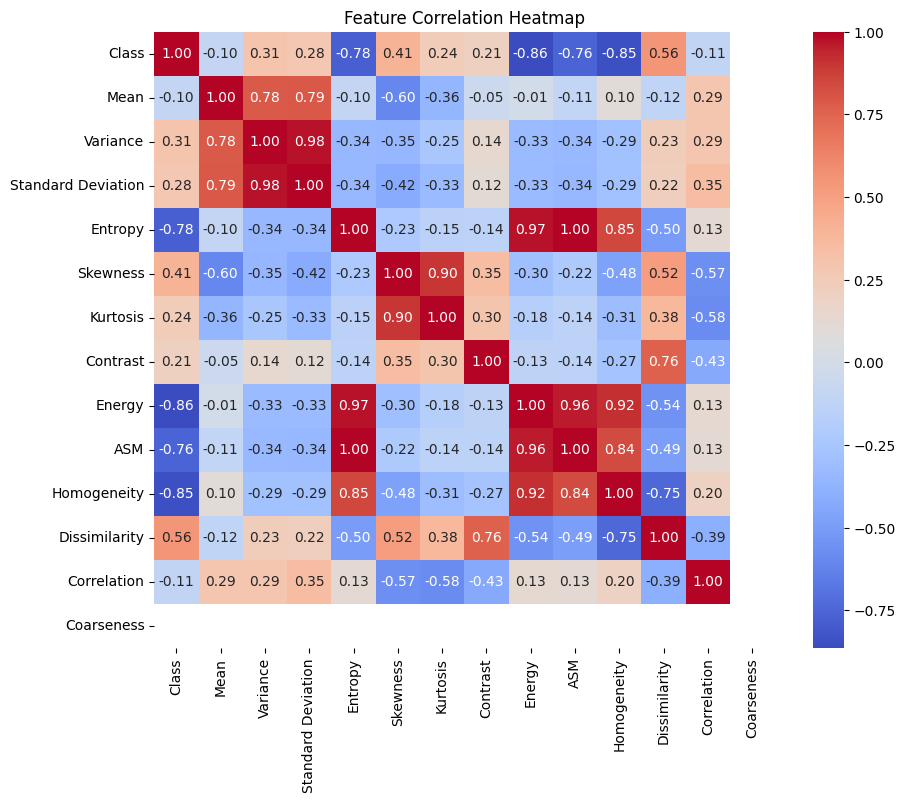

In [64]:
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

Observation: The heatmap confirms significant redundancy in the dataset, particularly among feature groups that provide nearly identical information. Variance and Standard Deviation are almost perfectly correlated (0.98), as are Entropy, Energy, and ASM (up to 1.00), and Skewness and Kurtosis (0.90). This high multicollinearity suggests that several of these features are redundant, and the model's complexity could be reduced by keeping only one representative variable from each highly correlated pair without losing meaningful data.

Question 4 : Do tumors typically appear "brighter" or "darker" on average compared to healthy tissue?



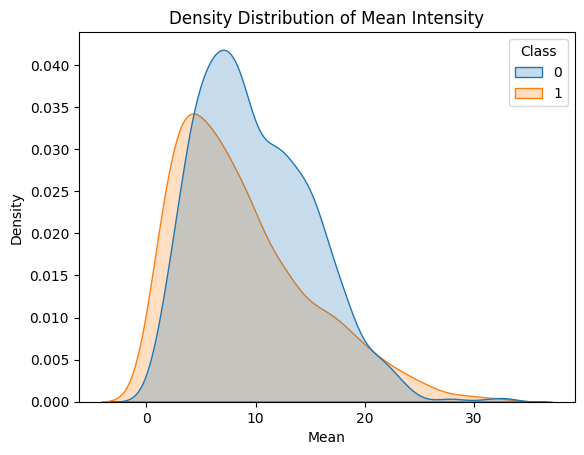

In [65]:
sns.kdeplot(data=data, x='Mean', hue='Class', fill=True)
plt.title('Density Distribution of Mean Intensity')
plt.show()

Observation: In this dataset, tumors typically appear darker on average. The density plot shows that the mean intensity for Class 1 (Tumor) peaks at a lower value than Class 0 (Healthy). Additionally, healthy tissue exhibits a broader distribution with higher variance, while tumorous samples are more concentrated in the lower-intensity range.

Question 5: When plotted together, do these two texture features create distinct clusters for each class?


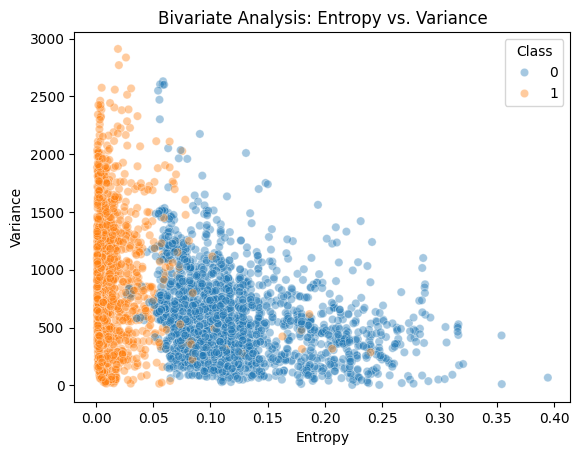

In [66]:
sns.scatterplot(data=data, x='Entropy', y='Variance', hue='Class', alpha=0.4)
plt.title('Bivariate Analysis: Entropy vs. Variance')
plt.show()

Observation: The scatter plot shows a clear clustering pattern, especially for Class 1 (Tumor), which has very low entropy. However, the classes overlap in the middle range (around 0.05–0.12), so they are not linearly separable. This means that while these features are useful, better accuracy will likely require additional features or a non-linear model.

Summary 

This exploratory analysis of the Brain Tumor dataset with 3,762 entries gave a clear understanding of the data quality and main patterns. After checking the dataset, 63 duplicate rows were removed and no missing values were found, so the data is clean and ready for modeling. 

From the visualizations, some important patterns appeared. Features like Entropy and Mean showed noticeable differences between the two classes. Tumor cases (Class 1) tend to have lower entropy and lower average intensity, meaning those regions are generally darker and less complex compared to healthy brain tissue.

One thing that stood out was the strong multicollinearity between features like Energy, ASM, and Entropy, which are almost identical in behavior. Also, the scatter plots showed overlap between classes in the middle ranges, meaning the separation is not very clear.

This raises some questions for modeling, such as whether a simple linear model will be enough or if more complex models will be needed to handle the overlap and redundant features.

In [67]:
data.to_csv('../data/cleaned.csv', index=False)